# Esercitazione 10
**7  Maggio 2024**

In [2]:
import numpy as np
import numpy.linalg as lin
import sympy as sym
import scipy.linalg as splin
import IPython.display as nb
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank as rank
from numpy.linalg import norm
from displayutils import display_matrix, display_vector, display_function
from itertools import takewhile
from system_solver import *
from functools import reduce 
from fractions import Fraction
from sympy.core.sympify import sympify 
from sympy.parsing.mathematica import parse_mathematica

markdown = lambda str: nb.display(nb.Markdown(str))
plt.style.use('dark_background')
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


### Codice EquazioniNormali
Implementare la function  **eqnorm(A,b)** che implementa il metodo delle equazioni normali per la soluzione del sistema sovradeterminato Ax=b e che prende in input:
- la matrice A di dimensione $m \times n$ , $m>n$
- il termine noto b di ordine m
restituisce in output
- la soluzione del sistema lineare 

In [11]:
def eqnorm(A, b):
    print(f"\nMetodo Equazioni Normali")
    m, n = A.shape
    if rank(A) < n:
        print(f'\n{bcolors.FAIL}La matrice non ha rango massimo{bcolors.ENDC}, rank → {rank(A)} n → {n}')
        return None
    G = A.T @ A
    if not all(lin.eigvals(G) > 0):
        print(f"{bcolors.FAIL}Matrice non definita positiva{bcolors.ENDC}")
        return None
    print(f"\nCondizionamento di G: {(lin.cond(G)):.3e}")
    # if lin.cond(G) > 10**4:
    #     print("Condizionamento troppo alto")
    #     return None
    
    x = cholensky_solve(G, A.T @ b)
    return x
    

### Codice QRLS
Implementare la function  **qrLS(A,b)** che utilizza il metodo QR per la soluzione del sistema sovradeterminato Ax=b e che prende in input:
- la matrice A di dimensione $m \times n$ , $m>n$
- il termine noto b di ordine m
restituisce in output
- la soluzione del sistema lineare e la norma 2 al quadrato del residuo.

In [12]:
def qrLS(A, b):
    m, n = A.shape
    print(f"\nMetodo Householder (Least Squared)")
    if rank(A) < n:
        print(f"\n{bcolors.FAIL}La matrice non ha rango massimo{bcolors.ENDC}, rank → {rank(A)} n → {n}")
        return None
    Q, R = splin.qr(A)
    R1 = R[0:n,:]
    print(f"\nCondizionamento di R1: {lin.cond(R):.3e}")
    h = Q.T @ b
    print(f"Residuo (norma 2) → {norm(h[n:])**2}")
    return Usolve(R1, h[0:n])


#Soluzione di un sistema sovradeterminato facendo uso della fattorizzazione QR    
def qrLS1(A,b):
    n=A.shape[1]  # numero di colonne di A
    #Calcola la fattorizzazione QR di A e utilizzala per calcolare
    #la soluzione nel senso dei minimi quadrati di Ax=b
    Q,R = splin.qr(A)
    h = Q.T@b
    x = Usolve(R[0:n,:],h[0:n])
    residuo = lin.norm(h[n:])**2
    return x


### Codice SVDLS
Implementare la function  **svdLS(A,b)** che utilizza  il metodo SVD per la soluzione del sistema sovradeterminato Ax=b e che prende in input:
- la matrice A di dimensione $m \times n$ , $m>n$
- il termine noto b di ordine m
restituisce in output
- la soluzione del sistema lineare e la norma 2 al quadrato del residuo.

In [13]:
def svdLS(A, b):
    U, S, VT = splin.svd(A)
    V = VT.T
    d = U.T @ b
    K = max(S)/min(S)
    print(f"\nMetodo Singular Value Decomposition (Least Squared)\nCondizionamento di A: {K:.3e}")
    c = d[:rank(A)] / S[:rank(A)]
    print(f"Residuo (norma 2) → {norm(d[rank(A):])**2}")
    return V[:,:rank(A)] @ c


## Esercizio 1
- Si utilizzino i tre metodi implementati  per l'approssimazione ai minimi quadrati delle seguenti configurazioni di dati:

$$
\begin{array}{l}
x_1 = [-3.5, \, -3, \, -2, \, -1.5, \, -0.5, \, 0.5, \, 1.7, \, 2.5, \, 3] ;\\
y_1 = [-3.9, \, -4.8, \, -3.3, \, -2.5, \, 0.3, \, 1.8, \, 4, \, 6.9, \, 7.1] ;\\
x_2 = [-3.14, \, -2.4, \, -1.57, \, -0.7, \, -0.3, \, 0, \, 0.4, \, 0.7, \, 1.57] ;\\
y_2 = [0.02, \, -1, \, -0.9, \, -0.72, \, -0.2, \, -0.04, \, 0.65, \, 0.67, \, 1.1] ;\\
x_3 = [[1.001,\, 1.004,\, 1.005,\,1.0012, \,1.0013,  \, 1.0014,  \, 1.0015, \, 1.0016] ;\\
y_3 = [-1.2, \, -0.95, \, -0.9, \, -1.15, \, -1.1, \, -1] ;\\
\end{array}
$$

al variare del grado $n$ tra 1 e 4.



In [14]:
def plot_regression(val, B, y, xv, mname):
    meth, sym, space = val
    alfa = meth(B, y)
    regress = lambda alfa, xv, B, y: np.polyval(np.flip(alfa), xv)
    if alfa is not None:
        plt.plot(xv, regress(alfa, xv, B, y), sym, dashes=(6, space), label=mname)
        

def test_data(x, y, B, methods):
    xv = np.linspace(min(x), max(x), 200)
    plt.plot(x, y, "yx", label='dati sperimentali')
    res = [plot_regression(val, B, y, xv, mname) for mname, val in methods.items()]
    plt.legend()

In [15]:
def least_squared(x, y, n, methods={'eqnormal':(eqnorm, 'c--', 0), 'qrLS':(qrLS, 'g-', 4), 'svdLS':(svdLS, 'r--', 5)}):
    m = len(x)
    B = np.vander(x, increasing=True)[:,:n + 1]
    plt.title(f"Plotting regression of data at order {n}")
    test_data(x, y, B, methods)
    print()
    plt.show()


Metodo Equazioni Normali

Condizionamento di G: 5.273e+00

Metodo Householder (Least Squared)

Condizionamento di R1: 2.296e+00
Residuo (norma 2) → 4.954617839084981

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 2.296e+00
Residuo (norma 2) → 4.954617839084981



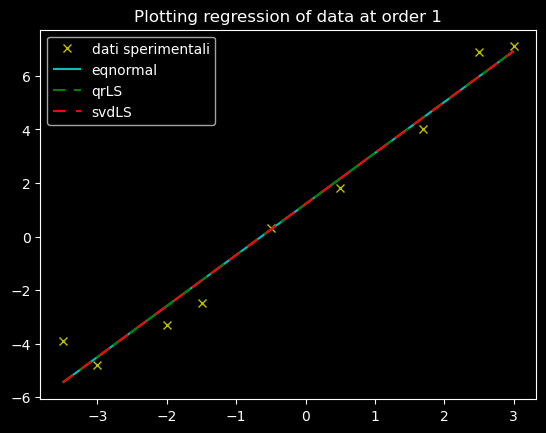


Metodo Equazioni Normali

Condizionamento di G: 3.398e+00

Metodo Householder (Least Squared)

Condizionamento di R1: 1.843e+00
Residuo (norma 2) → 2.1358347516238942

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 1.843e+00
Residuo (norma 2) → 2.1358347516238942



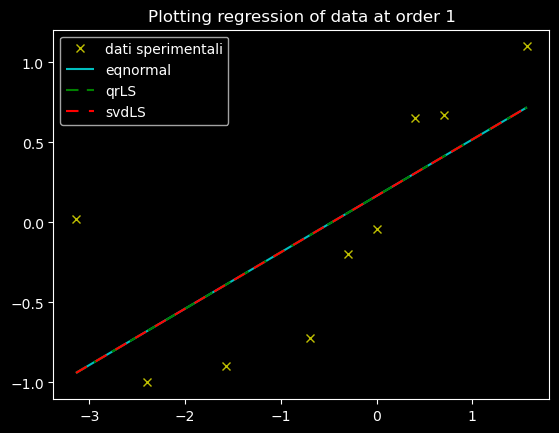


Metodo Equazioni Normali

Condizionamento di G: 1.031e+08

Metodo Householder (Least Squared)

Condizionamento di R1: 1.016e+04
Residuo (norma 2) → 0.06614285714287226

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 1.016e+04
Residuo (norma 2) → 0.06614285714287226



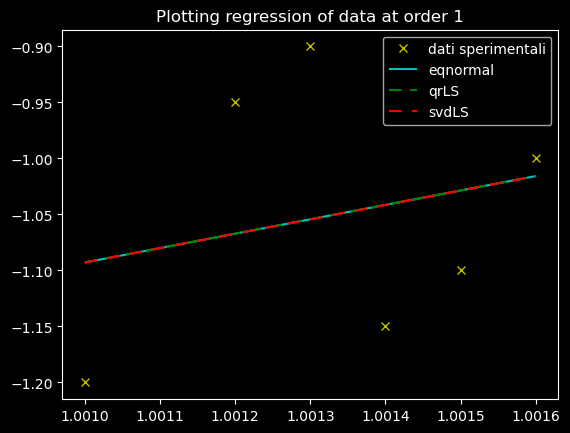

In [16]:
X = [[-3.5, -3, -2, -1.5, -0.5 , 0.5, 1.7, 2.5, 3],
     [-3.14, -2.4, -1.57, -0.7, -0.3, 0, 0.4, 0.7, 1.57],
    [1.001, 1.0012,1.0013, 1.0014, 1.0015, 1.0016]]
Y = [[-3.9, -4.8, -3.3,  -2.5, 0.3, 1.8, 4, 6.9, 7.1],
     [0.02, -1, -0.9, -0.72, -0.2, -0.04, 0.65, 0.67, 1.1],
     [-1.2, -0.95, -0.9, -1.15, -1.1, -1]]
n = 1
res = [least_squared(X[i], Y[i], n) for i in range(len(X))]

## Esercizio 2: 
Per i dati $(x_i, y_i)$ riportati nei seguenti array

$$
\begin{array}{l}
x = [0.0004, \, 0.2507, \, 0.5008, \, 2.0007, \, 8.0013]  ;\\
y = [0.0007, \, 0.0162, \, 0.0288, \, 0.0309, \, 0.0310] ;
\end{array}
$$

- costruire la retta di regressione;
- costruire la parabola approssimante i dati nel senso dei minimi quadrati;

Quale tra le due approssimazioni risulta la migliore? (Confrontare i grafici e la norma euclidea al quadrato del vettore dei residui).




Metodo Equazioni Normali

Condizionamento di G: 4.313e+03

Metodo Householder (Least Squared)

Condizionamento di R1: 6.567e+01
Residuo (norma 2) → 0.00023646355940249814



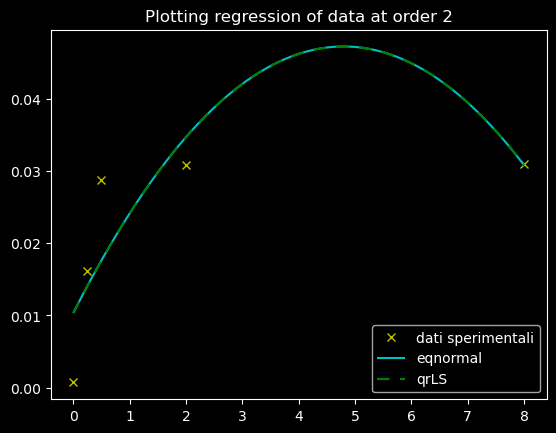

In [8]:
x = [0.0004, 0.2507, 0.5008, 2.0007, 8.0013]
y = [0.0007, 0.0162, 0.0288, 0.0309, 0.0310] 

n = 2
methods = {'eqnormal':(eqnorm, 'c--', 0), 'qrLS':(qrLS, 'g-', 5)}
least_squared(x, y, n, methods=methods)

## Esercizio 3:
Scrivere uno script Python per approssimare la seguente configurazione di punti

$$
\begin{array}{l}
x = [10 \, : \, 0.5/5 \, : \, 10.5] ;\\
y = [11.0320, \, 11.1263, \, 11.1339, \, 11.1339, \, 11.1993, \, 11.1844] ;
\end{array}
$$

mediante un polinomio ai minimi quadrati di grado 4 costruito  con il metodo
delle equazioni normali, con il metodo QRLS e con il metodo SVDLS.
Perturbare poi il secondo punto nel seguente modo
$$x(1) = x(1) + 0.013; \quad y(1) = y(1) - 0.001;$$
e calcolare i polinomi ai minimi quadrati relativi alla
configurazione perturbata. Commentare e motivare i risultati ottenuti.




Metodo Equazioni Normali

Condizionamento di G: 3.244e+19

Metodo Householder (Least Squared)

Condizionamento di R1: 3.565e+11
Residuo (norma 2) → 0.00017936015781063106

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 3.565e+11
Residuo (norma 2) → 0.0001793602216286103



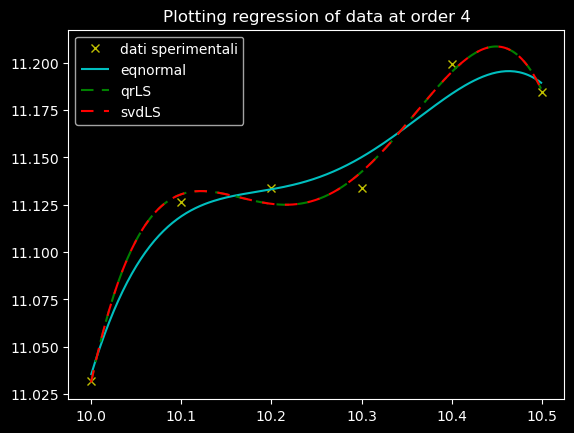


Metodo Equazioni Normali
Matrice non definita positiva

Metodo Householder (Least Squared)

Condizionamento di R1: 3.805e+11
Residuo (norma 2) → 0.00020144369553229326

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 3.805e+11
Residuo (norma 2) → 0.00020144381984670497



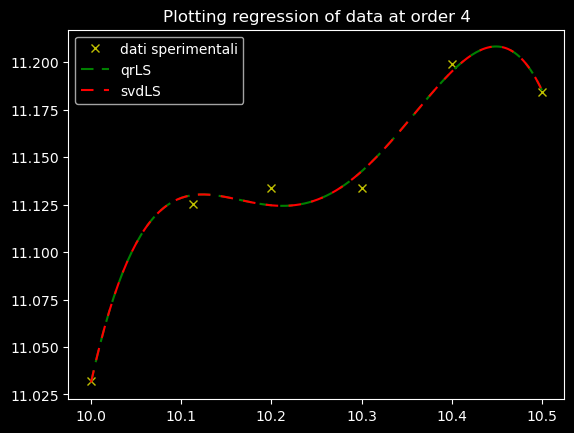

In [17]:
x = np.arange(10,10.6, 0.5/5)
y = np.array([11.0320, 11.1263, 11.1339, 11.1339, 11.1993, 11.1844])

n = 4
least_squared(x, y, n)

x[1] = x[1] + 0.013
y[1] = y[1] - 0.001

least_squared(x, y, n)

### Codici per l'interpolazione polinomiale nella forma di Lagrange 

Scrivere la function **interpL** che calcoli
il polinomio interpolante in forma di Lagrange  
Tale function deve assumere come dati in input:
 
 - x vettore dei nodi di interpolazione,
- y vettore dei valori della funzione nei nodi di interpolazione,
- xx vettore dei punti in cui si vuole valutare il polinomio interpolante.
 
In output deve essere restituito yy vettore contenente i valori assunti dal polinomio interpolante.

 
Funzioni Python  utili:
 
-  numpy.poly() restituisce i coefficienti di un polinomio di zeri assegnati,
 - numpy.polyval(p, x)  valuta un polinomio in un punto assegnato.
 

In [18]:
def print_lagrange(coeff, j, n):
    coeff = np.flip(coeff)
    str = reduce(lambda a, b: a + b, [f'+({Fraction(c)})*x^{i} ' for i, c in enumerate(coeff) if c != 0])
    g = parse_mathematica(str)
    display_function(g, f='L_{ '+f'{j}'+' }^{({ '+f'{n}'+' })}', varsym=sym.symbols(f"x"))

In [19]:
#calcolo del polinoimio di lagrange
def lagrange(xnodi: np, j: int, show=False):
    num = np.poly(xnodi[xnodi != xnodi[j]])
    den = np.polyval(num, xnodi[j])
    if show:
        print_lagrange(num / den, j, n)
    return num / den

In [21]:
def iterpL(x, y, xv): 
    return np.array([np.polyval(lagrange(x, j), xv) for j in range(len(x))]).T @ y
    

## Esercizio 1

Realizzare uno script che calcoli nella forma di Lagrange i polinomi che
interpolano le funzioni test $\sin(x)$ e $\cos(x)$ nei punti $x_k = k \pi/2$, con
$k = 0, 1, 2, 3, 4$. Visualizzare graficamente i polinomi ottenuti insieme
alle funzioni assegnate.

In [22]:
def plot_interp_func(x, y, xv):
    plt.plot(xv, y(xv), 'g-', label='funzione')
    plt.plot(x, y(x), 'X', label='punti di interpolazione')
    plt.plot(xv, iterpL(x, y(x), xv), 'r-', dashes=(4, 4), label='interpolazione')
    plt.legend()
    return iterpL(x, y(x), xv)
    

def plot_inter_generic(x, y, xv):
    plt.plot(x, y, 'X', label='punti di interpolazione')
    plt.plot(xv, iterpL(x, y, xv), 'r-', dashes=(4, 4), label='interpolazione')
    plt.legend()

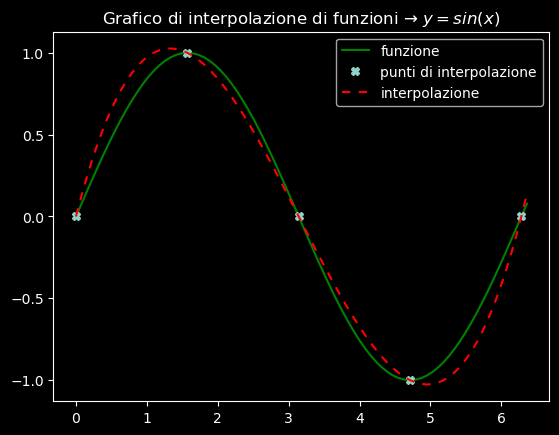

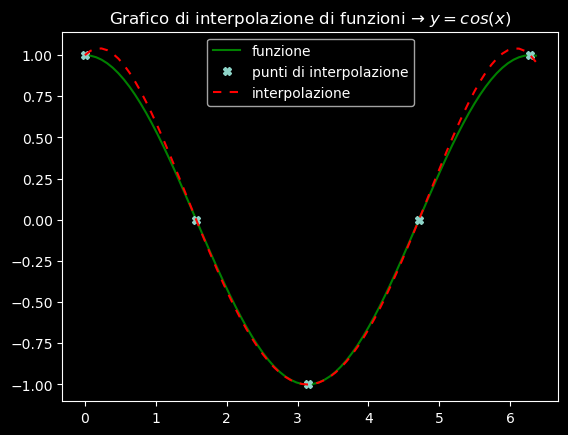

In [23]:
k = np.arange(0, 5)
xk= lambda k: np.pi * k / 2
y1 = lambda x: np.sin(x)
y2 = lambda x: np.cos(x)

x = xk(k)
xv = np.arange(0, 2*np.pi + 0.1, np.pi/40)
plt.title(r'Grafico di interpolazione di funzioni → $y=sin(x)$')
plot_interp_func(x, y1, xv)
plt.show()
plt.title(r'Grafico di interpolazione di funzioni → $y=cos(x)$')
plot_interp_func(x, y2, xv)
plt.show()

## Esercizio 2
Realizzare uno script python che interpola le coppie $x_i,y_i$, $i=0,\cdots,3$
dove $x_i,i=0,3$ sono punti equidistanti nell' intervallo [-1,1] e $y_i=f(x_i)$ dove $f(x)=3x^3+2x^2+2x-1$ 

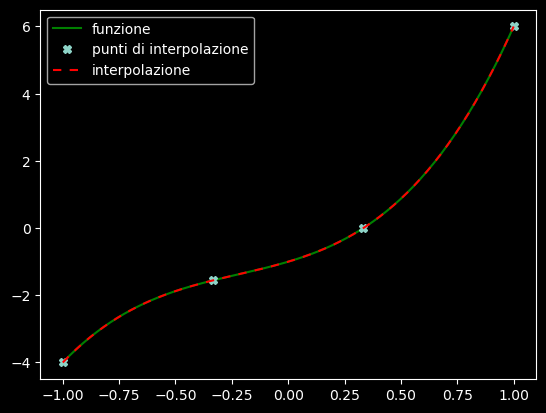

In [24]:
n = 3
x = np.linspace(-1, 1, 4)
f = lambda x: 3 * x**3 + 2*x**2 + 2*x - 1
y = f(x)
xv = np.linspace(-1, 1, 200)
plot_interp_func(x, f, xv)
plt.show()

## Esercizio 3

La temperatura $T$ in  prossimità  del suolo  subisce una variazione dipendente dalla latitudine $L$ nel seguente modo

L=np.array([-55, -45, -35, -25, -15, -5, 5, 15, 25, 35, 45, 55, 65])

T=np.array([3.7, 3.7,3.52,3.27, 3.2, 3.15, 3.15, 3.25, 3.47, 3.52, 3.65, 3.67, 3.52])


 
- Si vuole costruire un modello che descriva la legge $T = T(L)$ anche per latitudini non misurate. A tal fine si scriva uno script che fornisca la variazione di temperatura alle latitudini $L = \pm 42$ utilizzando il polinomio interpolante. Visualizzare in un grafico i dati assegnati, il polinomio interpolante e le stime di $T$ ottenute per $L = \pm 42$.


In [16]:
def scatter_estimate(i, st):
    x, y = (st, iterpL(L, T, [st]))
    plt.plot(x, y, 'bo', label=f'$s_{i} ({x}, {y[0]:.2f})$')   

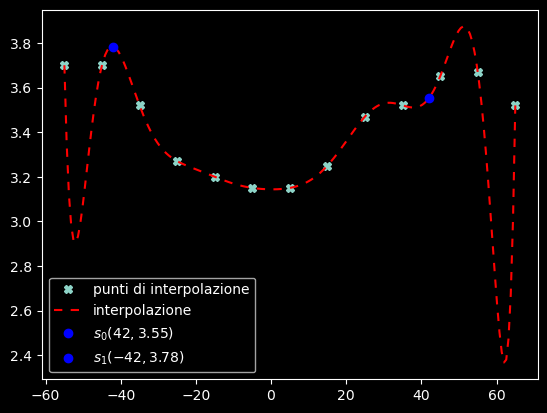

In [17]:
L=np.array([-55, -45, -35, -25, -15, -5, 5, 15, 25, 35, 45, 55, 65])
T=np.array([3.7, 3.7,3.52,3.27, 3.2, 3.15, 3.15, 3.25, 3.47, 3.52, 3.65, 3.67, 3.52])

xv = np.linspace(min(L), max(L), 200)

plot_inter_generic(L, T, xv)
stime = [42, -42]
[scatter_estimate(i, st) for i, st in enumerate(stime)]
plt.legend()
plt.show()

## Esercizio 4 

Scrivere uno script che calcoli il polinomio interpolante un insieme di punti $P_i =(x_i, y_i)$ $i = 0, ..., n $ nella forma di Lagrange con $x_i$ scelti dall'utente come:
    - punti equidistanti in un intervallo $[a, b]$,
    - punti definiti dai nodi di Chebyshev nell'intervallo $[a, b]$, ossia
$$
x_i = \frac{(a + b)}{2}+\frac{(b-a)}{2} \, \cos \left(
\frac{(2i+1)\pi}{2(n + 1)}
\right), \quad  i =0, ..., n 
$$
 
  e $y_i = f(x_i)$ ottenuti dalla valutazione nei punti $x_i$ di una funzione test   $f: \ [a, b] \rightarrow {\mathbb R}$. Testare lo script sulle funzioni
 
  - $f(x) = \sin(x)-2 \sin(2x)$,   $ \quad x \in [-\pi,\pi]$,
  -  $f(x) = \sinh(x)$, $ \quad  x \in [-2, 2]$,
  - $f(x) = |x|$,  $ \quad x \in [-1, 1]$,
  - $f(x) = 1/(1+25*x^2)$,  $ \quad x \in [-1, 1]$ (funzione di Runge).

Calcolare l'errore di interpolazione $r(x) = f(x)-p(x)$,
tra la funzione test $f(x)$ e il polinomio di interpolazione $p(x)$.
Visualizzare il grafico di $f(x)$ e $p(x)$, ed il grafico di
$|r(x)|$. Cosa si osserva? Cosa accade all'aumentare del grado $n$ di $p(x)$?
(Si costruisca una tabella che riporti i valori di $\|r(x)\|_{\infty}$ al variare di $n$).

In [25]:
line = lambda a, b, n: np.linspace(a, b, n+1)
sum = lambda a, b: ((a+b) / 2) + ((b-a) / 2)
cheb = lambda a, b, n: np.array([sum(a,b) * np.cos((2*i + 1) * np.pi /(2*(n+1))) for i in range(n+1)])

def eval_interp(interval, x_func, f, n, name, i):
    plt.subplot(1, 2, 1)
    a, b = interval
    x = x_func(a, b, n)
    xv = np.linspace(a, b, 200)
    plt.title(f'Interpolazione {name}')
    inter = plot_interp_func(x, f, xv)

    plt.subplot(1, 2, 2)
    plt.title(f'Errore di interpolazione rispetto\nalla funzione')
    err = np.abs(f(xv) - inter)
    plt.plot(xv, err, label=r'$||err||_{\infty}$'+f'→ {lin.norm(err,np.inf):.2f}')
    plt.legend()


In [26]:
symx = sym.Symbol('x')

def test_data(args):
    interv, f = args
    display_function(f(symx))
    f = sym.lambdify(symx, f(symx))
    for i, margs in enumerate(methods.items()):
        name, x_func = margs
        eval_interp(interv, x_func, f, n, name, i)   
        plt.tight_layout(pad=0.2)
        plt.show()

Choose function (0-4) 2


<IPython.core.display.Latex object>

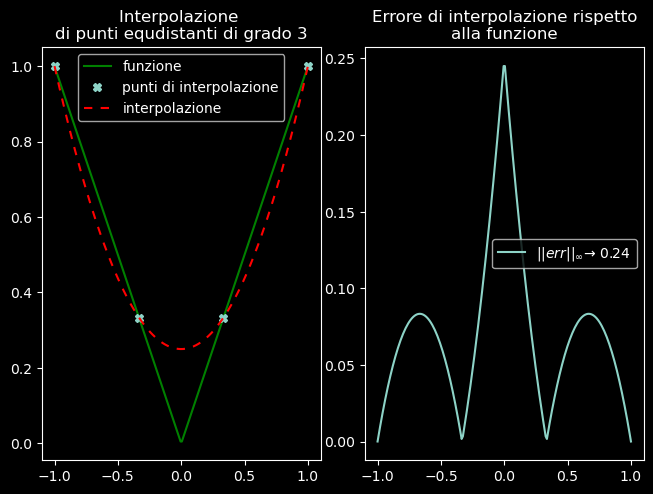

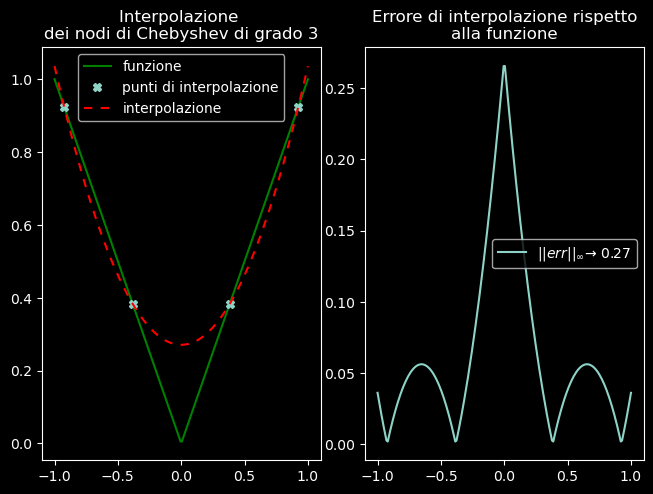

In [27]:
n = 3
menu = int(input('Choose function (0-4)'))
assert(n>0 and menu >= 0 and menu <= 4)
methods = { f'\ndi punti equdistanti di grado {n}':line, f'\ndei nodi di Chebyshev di grado {n}':cheb }

functions = [((-np.pi, np.pi), lambda x: sym.sin(x) - 2*(sym.sin(2*x))),
            ((-2, 2), lambda x: sym.sinh(x)),
            ((-1, 1), lambda x: abs(x)),
            ((-1, 1), lambda x: 1 / (1 + (25 * x**2)))
        ]

test_data(functions[menu])



## Esercizio 5

Per $n = 5, 10, 15, 20$ fornire un'approssimazione della costante di Lebesgue
scegliendo $x_1, x_2, ..., x_{n+1}$ equispaziati in $[-1, 1]$ oppure coincidenti con
i nodi di Chebyshev $x_i = \cos \left(\frac{(2i-1)\pi}{2(n + 1)}  \right)$, $i =1, ..., n + 1$.

In [26]:
n = 5
methods = { f'\ndi punti equdistanti di grado {n}':line, f'\ndei nodi di Chebyshev di grado {n}':cheb }

lebesgue = [((-np.pi, np.pi), lambda x: sym.sin(x) - 2*(sym.sin(2*x)))]


## Esercizio 6

Si interpolino mediante il polinomio $p_{21}(x)$ i 22 punti $(x_i, y_i)$ con $x_i$ equispaziati in $[-1, 1]$ e $y_i = \sin(2 \pi x_i)$. Si considerino poi le ordinate $\tilde{y}_i = y_i + \varepsilon_i$, dove $\varepsilon_i$ denota l'$i$-esima componente del vettore $0.0002*np.random.random(22,)$, e si calcoli il corrispondente
polinomio interpolante $\tilde{p}_{21}(x)$. Si visualizzino e si commentino
i risultati ottenuti, calcolando anche l'errore relativo sul polinomio interpolante
e sui dati.
